
Script générant un attaque adverse simple : rotation. On teste :

- Tous les angles pour toutes les images pour obtenir une accuracy moyenne du réseaux sur un data set en fonction de l'angle
- Tous les angle pour chaque image pour un label donné pour obtenir les angles maximisant ou minimisant la prediction d'un réseau sur ce label


> ... TODO ... # TODO test with rotation augmentation during training


In [2]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


# testing each network for different rotations

In [3]:
%ls -lh {data_cache}/{datetag}*results_test-rotations.json

-rwxrwxrwx 1 jnjer jnjer 52M May 30 20:23 cached_data/2024-05-24_bbox_resnet101_cartesian_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 30 19:29 cached_data/2024-05-24_bbox_resnet101_retino_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 30 22:41 cached_data/2024-05-24_bbox_resnet18_cartesian_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 30 22:11 cached_data/2024-05-24_bbox_resnet18_retino_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 30 21:41 cached_data/2024-05-24_bbox_resnet50_cartesian_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 30 21:05 cached_data/2024-05-24_bbox_resnet50_retino_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 31 00:38 cached_data/2024-05-24_focus_resnet101_cartesian_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 30 23:45 cached_data/2024-05-24_focus_resnet101_retino_results_test-rotations.json*
-rwxrwxrwx 1 jnjer jnjer 52M May 31 02:21 cached_data/2024-05-

In [4]:
# %rm {data_cache}/*results_test-rotations.json 

In [5]:
%ls -l 'cached_data/2024-05-14_full_resnet101_do_polar=True_results_test-rotations.json'

-rwxrwxrwx 1 jnjer jnjer 53901213 May 17 11:55 'cached_data/2024-05-14_full_resnet101_do_polar=True_results_test-rotations.json'*


In [6]:
args.batch_size_val = 1

In [6]:
angles = np.linspace(-180, 180, 24, endpoint=False)

In [7]:
delta_angle = angles[1] - angles[0]
angles_min = angles - delta_angle/2
angles_max = angles + delta_angle/2

# Loading and testing the networks
for data_set_type in data_set_types:
    
    print(50*'=')
    print(f'{data_set_type=}')
    args = Params()
    #args.do_rotation = True
    args.do_rot_train = True
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')
        
    for model_name, lw in  zip(['resnet101', 'resnet50', 'resnet18'], [4, 2, 1]): #, 
        print(f'{model_name=}')

        for do_polar in [True, False]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-rotations.json'
            if os.path.isfile(df_filename):
                df_angle = pd.read_json(df_filename)
            else:
                print(f'Computing {df_filename}')
                results = np.zeros((0, 3))
                model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'

                if os.path.isfile(model_filename):
                    print(f"Loading pre-trained resnet {model_filename}")
                    model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

                    for angle, angle_min, angle_max in zip(angles, angles_min, angles_max):
                        print(f'{angle=}', end='')
                        args.angles = [angle_min, angle_max]
                        dataloaders = datasets_transforms(args, shuffle=False, verbose=False)
                        with torch.no_grad():
                            for i_image, (images, labels) in enumerate(dataloaders['val']):
                                images, labels = images.to(device), labels.to(device)

                                outputs = model(images)

                                _, preds = torch.max(outputs.data, dim=1)
                                detect = (preds == labels.data).cpu().numpy()

                                results_ = np.vstack([i_image*args.batch_size_val + np.arange(len(detect)), angle*np.ones(len(detect)), detect]).T
                                results = np.vstack((results, results_))
                        print(f', Accuracy={detect.mean():.3f}')
                    df_angle = pd.DataFrame(results, columns=['i_image', 'angle', 'match'])     
                    df_angle.to_json(df_filename)                        
                    print(25*'. ')

    print(50*'=')

data_set_type='full'
--------------------------------------------------
model_name='resnet101'
args.do_polar=True
..................................................
Computing cached_data/2024-05-24_full_resnet101_retino_results_test-rotations.json
Loading pre-trained resnet cached_data/2024-05-24_full_resnet101_retino.pt
loading .... cached_data/2024-05-24_full_resnet101_retino.pt
angle=-180.0, Accuracy=0.580
angle=-165.0

KeyboardInterrupt: 

In [ ]:
skuu

# analysis: average accuracy for different rotations

In [12]:
df_angle['angle'].unique()

array([-180, -165, -150, -135, -120, -105,  -90,  -75,  -60,  -45,  -30,
        -15,    0,   15,   30,   45,   60,   75,   90,  105,  120,  135,
        150,  165])

In [13]:
args.angles

array([-180, -173, -166, -158, -151, -144, -136, -129, -122, -114, -107,
       -100,  -92,  -85,  -78,  -70,  -63,  -56,  -48,  -41,  -34,  -26,
        -19,  -12,   -4,    3,   11,   18,   25,   33,   40,   47,   55,
         62,   69,   77,   84,   91,   99,  106,  113,  121,  128,  135,
        143,  150,  157,  165,  172,  180])

In [7]:
data_set_types

['full', 'bbox', 'focus']

model_name='resnet18'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------


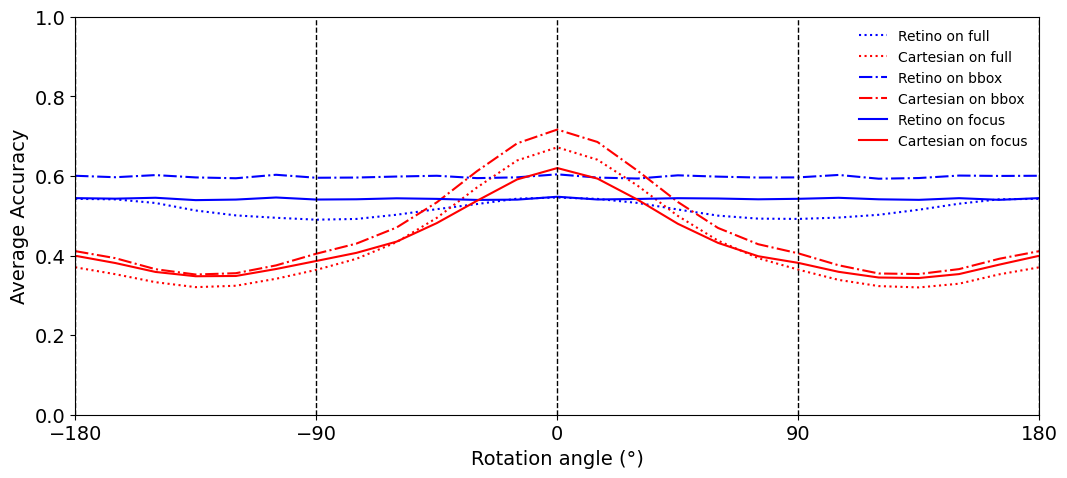

model_name='resnet50'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------


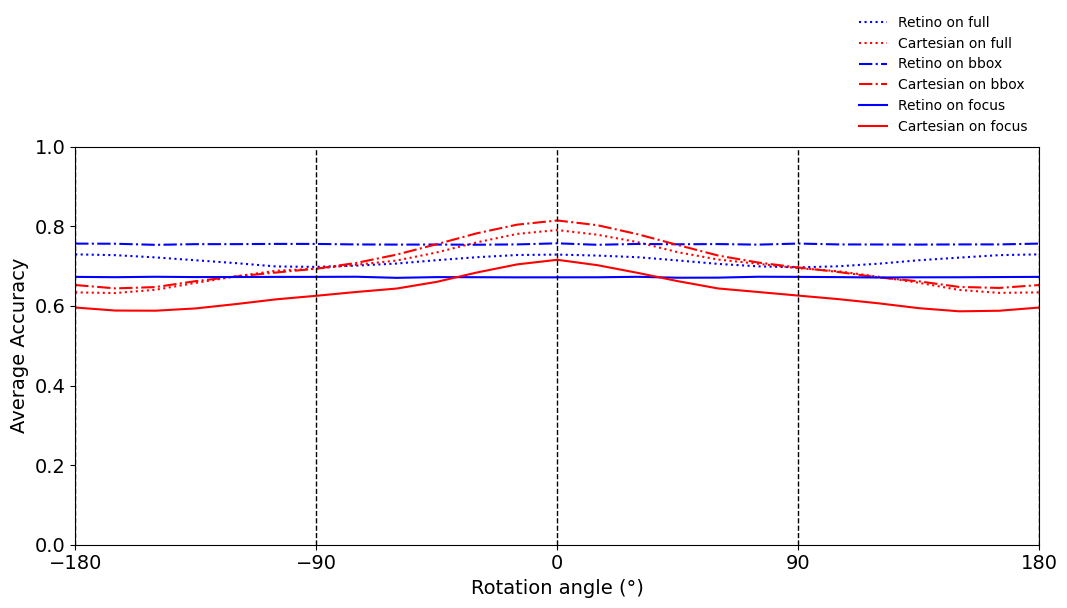

model_name='resnet101'
data_set_type='full'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------


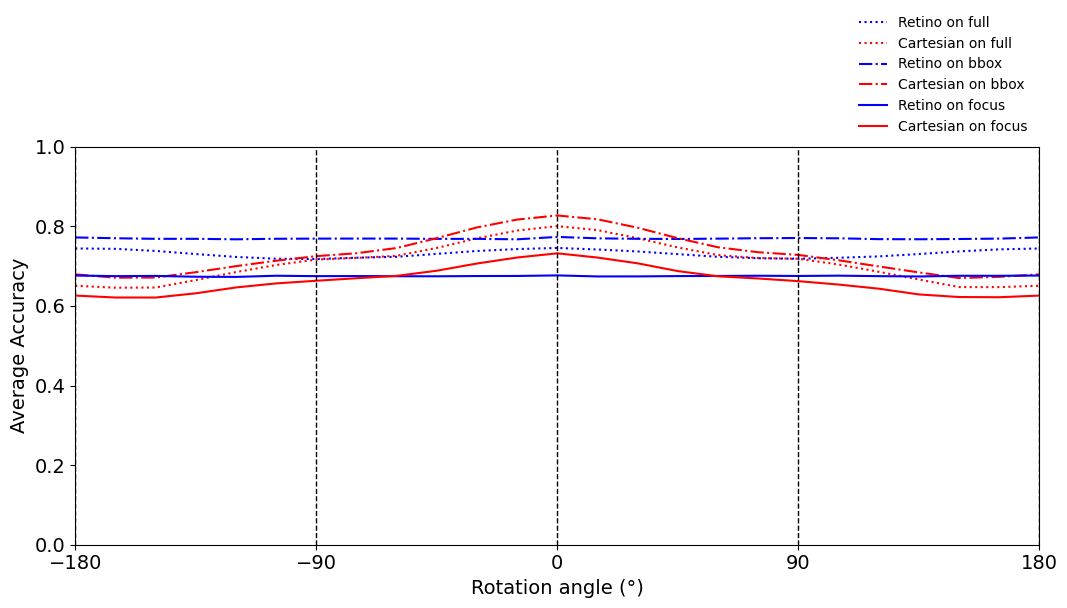

In [14]:
for model_name in  ['resnet18', 'resnet50', 'resnet101', ]:
    print(50*'=')
    print(f'{model_name=}')
    fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
    for data_set_type, ls in zip(data_set_types, data_set_linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([True, False], ['b', 'r']):

            df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-rotations.json'

            if os.path.isfile(df_filename):
                df_angle = pd.read_json(df_filename)

                results = [df_angle[df_angle['angle'] == angle]['match'].mean() for angle in np.hstack((df_angle['angle'].unique(), -180.))]
                label = 'Retino' if do_polar else 'Cartesian'
                label += f' on {data_set_type}'
                ax.plot(np.hstack((df_angle['angle'].unique(), 180)), results, color=color, ls=ls, label=label)
        
    #ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlim(-180, 180)
    ax.set_ylim(0, 1)

    for angle in [-180, -90, 0, 90, 180]:
        ax.axvline(x=angle, c='k', ls='--', lw=1)
    ax.set_xticks([-180, -90, 0, 90, 180])
    #ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
    #ax.set_yticks([.7, .75, .8])
    ax.set_ylabel('Average Accuracy', font=font)
    ax.set_xlabel('Rotation angle (°)', font=font)
    plt.legend(bbox_to_anchor=(0.8, 1), loc='best', fontsize=10, edgecolor='none')
    plt.tight_layout()
    # plt.xticks(font=font)
    # plt.yticks(font=font);
    plt.show()

# analysis: rotation attacks

In [11]:
df_angle

,i_image,angle,match
0,0,-180,1
1,1,-180,1
2,2,-180,1
3,3,-180,1
4,4,-180,1
...,...,...,...
1117771,46569,165,1
1117772,46570,165,0
1117773,46571,165,0
1117774,46572,165,1


In [12]:
df_angle[df_angle['angle']==0]['match'].mean()

0.9034869240348692

In [13]:
i_images = df_angle['i_image'].unique()
df_angle['i_image'].shape, i_images.shape

((1117776,), (46574,))

In [14]:
i_image = 0

In [15]:
all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
all_rot_matches, all_rot_matches.min(), all_rot_matches.max()

(0          1
 46574      1
 93148      1
 139722     1
 186296     1
 232870     1
 279444     1
 326018     1
 372592     1
 419166     1
 465740     1
 512314     1
 558888     1
 605462     1
 652036     1
 698610     1
 745184     1
 791758     1
 838332     1
 884906     1
 931480     1
 978054     1
 1024628    1
 1071202    1
 Name: match, dtype: int64,
 1,
 1)

In [16]:
# for i_image in i_images:
#     all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
#     if not(all_rot_matches.max() == all_rot_matches.min()):  
#         print(f'{i_image=}, {all_rot_matches}')

In [17]:
json_filename = f'{data_cache}/{datetag}_rotation_attack.json'


if os.path.isfile(json_filename):
    print(f"Load pre-computed {json_filename=}")
    df_attack = pd.read_json(json_filename, orient='index')
else:
    df_attack = pd.DataFrame([], columns=['model_name', 'data_set_type', 'do_polar', 'accuracy_before_attack', 'accuracy_after_attack']) 

    for model_name in ['resnet18', 'resnet50', 'resnet101', ]:
        print(50*'=')
        print(f'{model_name=}')
        # fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
        for data_set_type in data_set_types:
            print(50*'-')
            print(f'{data_set_type=}')
            print(50*'-')

            for do_polar, color in zip([True, False], ['b', 'r']):

                df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_test-rotations.json'

                if os.path.isfile(df_filename):
                    df_angle = pd.read_json(df_filename)
                    accuracy_before_attack = df_angle[df_angle['angle']==0]['match'].mean() 

                    i_images = df_angle['i_image'].unique()
                    score = 0
                    # true_positives = 0
                    for i_image in i_images:
                        all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
                        # if all_rot_matches.min() < all_rot_matches.max():  
                        #     score += 1 # attack succeeded !                        
                        # if all_rot_matches.max() == 1: true_positives += 1
                        # if all_rot_matches.max() == 1: true_positives += 1
                        if all_rot_matches.min() == 0: score += 1 # attack succeeded !
                    accuracy_after_attack = (len(i_images)-score)/len(i_images)
                    print(f'{data_set_type=}, {do_polar=}, {accuracy_before_attack=:.3f} -  {accuracy_after_attack=:.3f}')

                    df_attack.loc[len(df_attack.index)] = [model_name, data_set_type, do_polar, accuracy_before_attack, accuracy_after_attack]

    df_attack.to_json(json_filename, orient='index', indent=2)


model_name='resnet50'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
data_set_type='full', do_polar=True, accuracy_before_attack=0.727 -  accuracy_after_attack=0.525
data_set_type='full', do_polar=False, accuracy_before_attack=0.784 -  accuracy_after_attack=0.407
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='bbox', do_polar=True, accuracy_before_attack=0.663 -  accuracy_after_attack=0.515
data_set_type='bbox', do_polar=False, accuracy_before_attack=0.738 -  accuracy_after_attack=0.356
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------
data_set_type='focus', do_polar=True, accuracy_before_attack=0.842 -  accuracy_after_attack=0.705
data_set_type='focus', do_polar=False, accuracy_before_attack=0.872 -  accuracy_after_attack=0.486
model_name='resnet18'

In [18]:
df_attack_ = df_attack[(df_attack['model_name'] == model_name) & (df_attack['data_set_type'] == data_set_type) & (df_attack['do_polar'] == do_polar)]

In [19]:
df_attack_['accuracy_before_attack'].item()

0.9034869240348692

In [20]:
json_filename = f'{data_cache}/{datetag}_rotation_attack.json'


if os.path.isfile(json_filename):
    print(f"Load pre-computed {json_filename=}")
    df_attack = pd.read_json(json_filename, orient='index')
else:
    df_attack = pd.DataFrame([], columns=['model_name', 'data_set_type', 'do_polar', 'accuracy_before_attack', 'accuracy_after_attack']) 

    for model_name in ['resnet50', 'resnet18', 'resnet101', ]:
        print(50*'=')
        print(f'{model_name=}')
        # fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
        for data_set_type, ls in zip(data_set_types, linestyles):
            print(50*'-')
            print(f'{data_set_type=}')
            print(50*'-')

            for do_polar, color in zip([True, False], ['b', 'r']):
                a
                if os.path.isfile(df_filename):
                    df_angle = pd.read_json(df_filename)
                    accuracy_before_attack = df_angle[df_angle['angle']==0]['match'].mean() 

                    i_images = df_angle['i_image'].unique()
                    score = 0
                    for i_image in i_images:
                        all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
                        # if not(all_rot_matches.max() == all_rot_matches.min()):  
                        if all_rot_matches.min() < all_rot_matches.max():  
                            score += 1 # attack succeeded !
                    accuracy_after_attack = (len(i_images)-score)/len(i_images)
                    print(f'{data_set_type=}, {do_polar=}, {accuracy_before_attack=:.3f} -  {accuracy_after_attack=:.3f}')

                    df_attack.loc[len(df_attack.index)] = [model_name, data_set_type, do_polar, accuracy_before_attack, accuracy_after_attack]

    df_attack.to_json(json_filename, orient='index', indent=2)


Load pre-computed json_filename='cached_data/2024-05-14_rotation_attack.json'


In [21]:
json_filename = f'{data_cache}/{datetag}_rotation_attack.json'


if os.path.isfile(json_filename):
    print(f"Load pre-computed {json_filename=}")
    df_attack = pd.read_json(json_filename, orient='index')




    for model_name in ['resnet18', 'resnet50', 'resnet101', ]:
        print(50*'=')
        print(f'{model_name=}')
        # fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
        for data_set_type, ls in zip(data_set_types, linestyles):
            print(50*'-')
            print(f'{data_set_type=}')
            print(50*'-')

            for do_polar in [True, False]:

                df_attack_ = df_attack[(df_attack['model_name'] == model_name) & (df_attack['data_set_type'] == data_set_type) & (df_attack['do_polar'] == do_polar)]
                print(f'{data_set_type=}, {do_polar=}, {df_attack_['accuracy_before_attack'].item()=:.3f} -  {df_attack_['accuracy_after_attack'].item()=:.3f}')



Load pre-computed json_filename='cached_data/2024-05-14_rotation_attack.json'
model_name='resnet18'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
data_set_type='full', do_polar=True, df_attack_['accuracy_before_attack'].item()=0.554 -  df_attack_['accuracy_after_attack'].item()=0.294
data_set_type='full', do_polar=False, df_attack_['accuracy_before_attack'].item()=0.663 -  df_attack_['accuracy_after_attack'].item()=0.112
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='bbox', do_polar=True, df_attack_['accuracy_before_attack'].item()=0.508 -  df_attack_['accuracy_after_attack'].item()=0.339
data_set_type='bbox', do_polar=False, df_attack_['accuracy_before_attack'].item()=0.627 -  df_attack_['accuracy_after_attack'].item()=0.111
--------------------------------------------------
data_set_type='focus'
-----------------------

In [22]:
df_attack

,model_name,data_set_type,do_polar,accuracy_before_attack,accuracy_after_attack
0,resnet50,full,True,0.726585,0.524890
1,resnet50,full,False,0.783764,0.407212
2,resnet50,bbox,True,0.663432,0.514880
3,resnet50,bbox,False,0.737900,0.355530
4,resnet50,focus,True,0.841736,0.704556
5,resnet50,focus,False,0.872268,0.486409
6,resnet18,full,True,0.554269,0.293674
7,resnet18,full,False,0.663407,0.112038
8,resnet18,bbox,True,0.508207,0.339140
9,resnet18,bbox,False,0.627335,0.111423
